In [2]:
# 필요한 라이브러리 임포트
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder  # 올바른 모듈 이름
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import seaborn as sns

In [3]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정
font_path = 'C:/Windows/Fonts/malgun.ttf'  # Windows의 Malgun Gothic
# font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'  # Linux의 Nanum Gothic
fontprop = fm.FontProperties(fname=font_path)

plt.rc('font', family=fontprop.get_name())  # 전체 폰트 설정
plt.rcParams['axes.unicode_minus'] = False  # 한글 폰트 사용 시 음수 깨짐 방지

### 데이터 로드 및 확인

In [4]:
# 데이터 로드
train_path = 'C:/Users/Admin/Desktop/dacon_data/train.csv'
test_path = 'C:/Users/Admin/Desktop/dacon_data/test.csv'
sample_submission_path = 'C:/Users/Admin/Desktop/dacon_data/sample_submission.csv'

In [5]:
# 데이터 읽기
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample_submission = pd.read_csv(sample_submission_path)

In [6]:
# 데이터 크기 확인
print("Train 데이터 크기:", train.shape)
print("Test 데이터 크기:", test.shape)
print("Sample Submission 데이터 크기:", sample_submission.shape)

Train 데이터 크기: (31684, 5)
Test 데이터 크기: (7920, 4)
Sample Submission 데이터 크기: (7920, 2)


In [7]:
# 결측치 탐지
print("\n[결측치 탐지]")
print(train.isnull().sum())


[결측치 탐지]
index           0
송하인_격자공간고유번호    0
수하인_격자공간고유번호    0
물품_카테고리         0
운송장_건수          0
dtype: int64


In [8]:
# 이상치 탐지 (기본적인 IQR 방식)
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

print("\n[이상치 탐지]")
for col in train.select_dtypes(include=[np.number]).columns:
    outliers = detect_outliers(train, col)
    print(f"'{col}'에서 발견된 이상치 수: {len(outliers)}")


[이상치 탐지]
'index'에서 발견된 이상치 수: 0
'송하인_격자공간고유번호'에서 발견된 이상치 수: 7062
'수하인_격자공간고유번호'에서 발견된 이상치 수: 0
'운송장_건수'에서 발견된 이상치 수: 2475


이상치가 7062건 발견되었으나, '송하인_격자공간고유번호'는 공간을 나타내는 고유 번호로 보입니다.

In [9]:
# 열 이름 확인
print("Train 데이터 열 이름:", train.columns)
print("Test 데이터 열 이름:", test.columns)

Train 데이터 열 이름: Index(['index', '송하인_격자공간고유번호', '수하인_격자공간고유번호', '물품_카테고리', '운송장_건수'], dtype='object')
Test 데이터 열 이름: Index(['index', '송하인_격자공간고유번호', '수하인_격자공간고유번호', '물품_카테고리'], dtype='object')


### 범주형 변수 인코딩
물품_카테고리는 범주형 변수이므로 모델이 이해할 수 있도록 숫자로 변환합니다. 범주 수가 100개로 비교적 크고, 모델링 파트에서 트리 기반 모델을 사용할 예정이므로 Label Encoding을 사용했습니다.

In [10]:
# 데이터 합치기
combined = pd.concat([train, test], axis=0)

In [11]:
# Label Encoding
label_encoder = LabelEncoder()
combined['물품_카테고리'] = label_encoder.fit_transform(combined['물품_카테고리'])

In [12]:
# 다시 데이터 분리
train['물품_카테고리'] = combined.iloc[:len(train), :]['물품_카테고리']
test['물품_카테고리'] = combined.iloc[len(train):, :]['물품_카테고리']

In [13]:
# 변환된 값 확인
print(train['물품_카테고리'].unique())

[67 34 27 17 51 57 56  5 66  3 54 80 97 14 69 15 41  6 35 16 81 36 61 11
 44 93 33 47 29 19 25 26 45 46 21 30 31 77 42 85 84 71 59 90 10 70  1 89
 95 75  0 96 22 64 86  4 76 23 74 72 40 78  9  2 49 68 73 92 60 63 55 50
 83 58  8 99 88 24 39 38 98 94 32 87 12 28 18 20 13 37 62 53  7 43 65 82
 48 91 52 79]


In [14]:
# 상위 데이터 확인
print(test['물품_카테고리'].unique())

[47 12 88 58 39 89 84  4 22 35  0 59 62 24 73 75 37 21 32  9 95 49 87 10
  6 76 14 72 57 56 80 71 74 82 50 99 67 31 77 90  1  5 66 15 27 51 93 19
 44 16 17 36 18 25  3 34 28 11 38  8 26 54 61 78 41 86 97 70 69 43 29 33
 68 60 13 23 40 42 63 91 83 85 81 45 20 46 53 96 94 92 98 64 30 52 55  2
 79 65 48  7]


In [15]:
print(train.head())

   index      송하인_격자공간고유번호      수하인_격자공간고유번호  물품_카테고리  운송장_건수
0      0  5011000595017300  2871000192069300       67       3
1      1  4148000690043300  5011000264024400       34       3
2      2  5011000078068400  1120000007005400       27       3
3      3  4127100048006400  5011000587019400       17       7
4      4  5011000078068400  2823700010076300       27       3


In [16]:
print(test.head())

   index      송하인_격자공간고유번호      수하인_격자공간고유번호  물품_카테고리
0      0  4167000577042200  5011000435014100       47
1      1  1156000009012200  5011000172034400       12
2      2  4122000363057300  5011000361097300       88
3      3  5011000436041400  2826000084036400       58
4      4  4150000241065200  5011000169044300       39


In [17]:
# 데이터 유형 확인
print(train['물품_카테고리'].dtype)
print(test['물품_카테고리'].dtype)

int32
int32


In [18]:
# 범주와 숫자의 매핑 확인
categories = label_encoder.classes_  # 학습된 모든 범주

for idx, category in enumerate(categories):
    print(f"{category} -> {idx}")

DIY자재/용품 -> 0
PC -> 1
PC주변기기 -> 2
가공식품 -> 3
가방 -> 4
건강식품 -> 5
건강용품 -> 6
게임기/타이틀 -> 7
계절가전 -> 8
골프 -> 9
공구 -> 10
과자 -> 11
구강위생용품 -> 12
기능성 -> 13
기저귀/물티슈 -> 14
기타디지털/가전 -> 15
기타스포츠/레저 -> 16
기타식품 -> 17
기타출산/육아 -> 18
기타패션의류 -> 19
기타패션잡화 -> 20
기타화장품/미용 -> 21
김치 -> 22
낚시 -> 23
남성화장품 -> 24
냉동/간편조리식품 -> 25
네일케어 -> 26
농산물 -> 27
눈관리용품 -> 28
다이어트식품 -> 29
등산 -> 30
모니터 -> 31
모자 -> 32
문구/사무용품 -> 33
문화컨텐츠 -> 34
바디케어 -> 35
반려동물 -> 36
반찬 -> 37
베이스메이크업 -> 38
분유/이유식/아기간식 -> 39
뷰티소품 -> 40
상의 -> 41
색조메이크업 -> 42
생활가전 -> 43
생활용품 -> 44
서재/사무용가구 -> 45
선글라스/안경테 -> 46
선케어 -> 47
세탁용품 -> 48
수납/정리용품 -> 49
수납가구 -> 50
수산 -> 51
스마트디바이스 -> 52
스마트디바이스액세서리 -> 53
스킨케어 -> 54
스포츠잡화 -> 55
신발 -> 56
아우터 -> 57
아웃도어가구 -> 58
양말/스타킹 -> 59
언더웨어 -> 60
완구/매트 -> 61
욕실용품 -> 62
원피스/점프슈트 -> 63
위생/건강용품 -> 64
유아가구 -> 65
음료 -> 66
음반 -> 67
음향가전 -> 68
의료용품 -> 69
이미용가전 -> 70
인테리어소품 -> 71
자동차용품 -> 72
잠옷 -> 73
재활운동용품 -> 74
주방가구 -> 75
주방가전 -> 76
주방용품 -> 77
주얼리 -> 78
지갑 -> 79
축산 -> 80
출산/유아동의류 -> 81
출산/유아동잡화 -> 82
취미용품 -> 83
침구단품 -> 84
침구세트 -> 85


### 타겟 변수 확인
운송량 분포를 확인하여 필요시 로그 변환과 같은 방법으로 정규성을 확보하려고 했습니다.

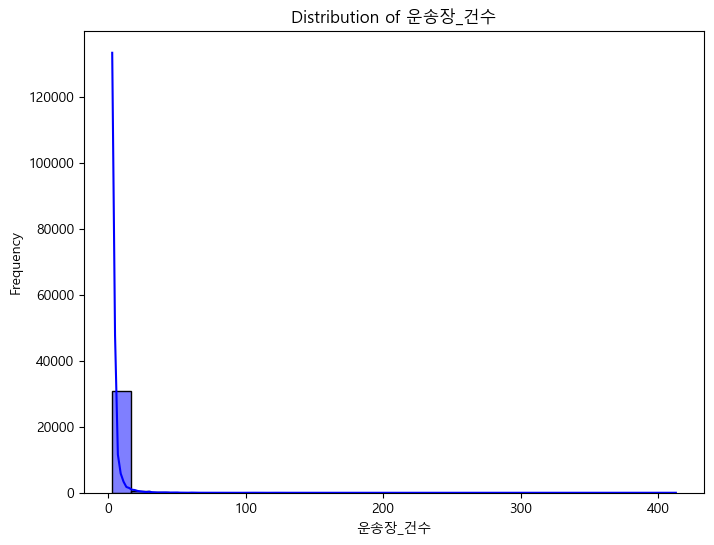

In [19]:
# 연속형 변수 분포 확인 (운송장_건수 예시)
plt.figure(figsize=(8, 6))
sns.histplot(train['운송장_건수'], kde=True, bins=30, color='blue')
plt.title("Distribution of 운송장_건수")
plt.xlabel("운송장_건수")
plt.ylabel("Frequency")
plt.show()

- 대부분의 데이터가 0~10 사이에 몰려 있습니다. 대다수의 송하인/수하인은 상대적으로 적은 물량을 송신하며, 특정 소수의 송하인만 대규모의 물량을 처리하는 패턴을 확인하였습니다.

- 모델 학습과 일반화를 위해 로그 변환을 실행했습니다.

In [20]:
# 로그 변환
train['운송장_건수_log'] = np.log1p(train['운송장_건수'])

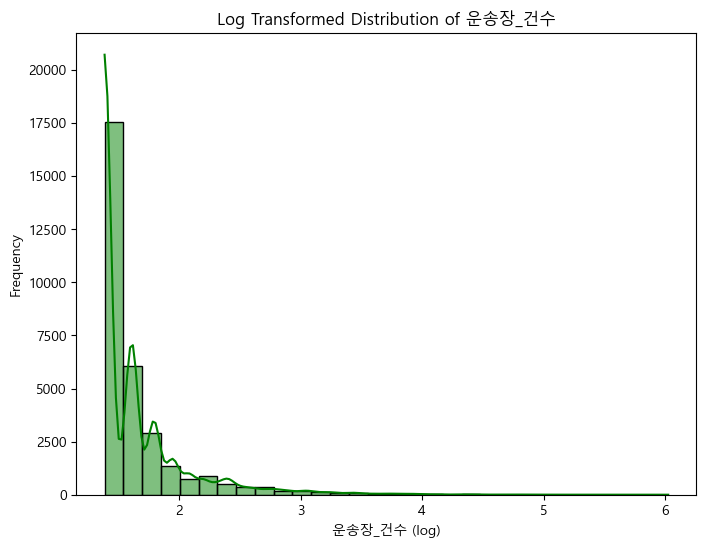

In [21]:
# 변환 후 분포 확인
plt.figure(figsize=(8, 6))
sns.histplot(train['운송장_건수_log'], kde=True, bins=30, color='green')
plt.title("Log Transformed Distribution of 운송장_건수")
plt.xlabel("운송장_건수 (log)")
plt.ylabel("Frequency")
plt.show()

### 변수 간 상관관계 분석

상관관계는 변수 간의 관계를 파악하는 데 유용합니다. 이를 통해 모델링에 중요한 변수들을 식별할 수 있습니다.

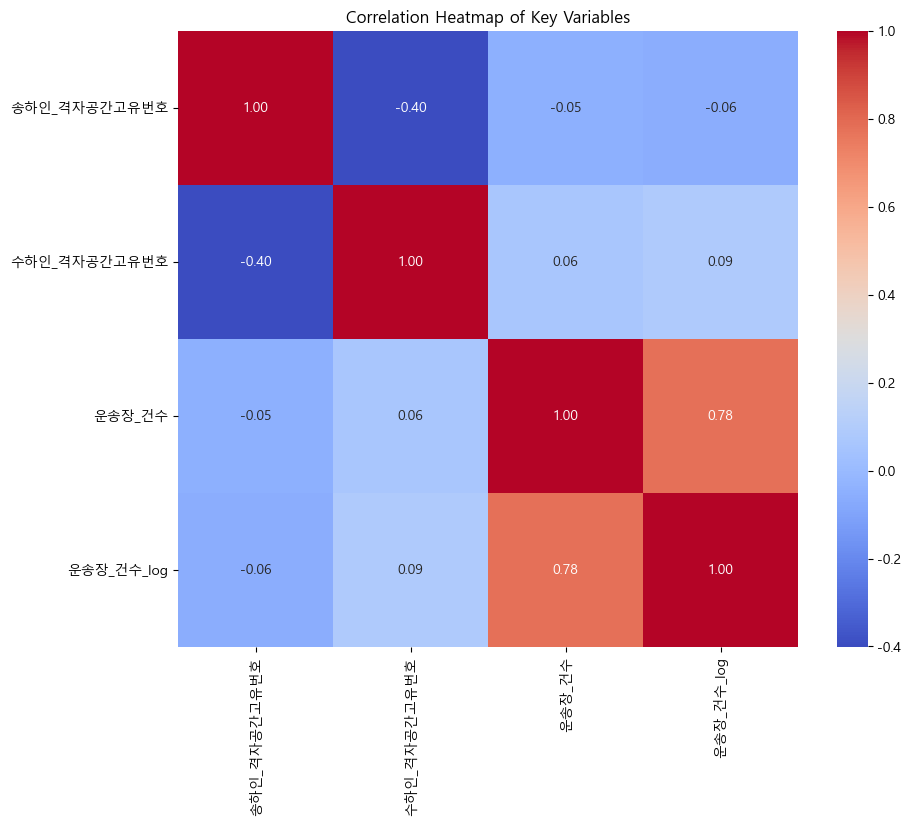

In [22]:
# 주요 변수 간 상관관계 계산
correlation_matrix = train[['송하인_격자공간고유번호', '수하인_격자공간고유번호', '운송장_건수', '운송장_건수_log']].corr()

# 상관관계 히트맵 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap of Key Variables")
plt.show()

- 강한 상관관계: 운송장_건수와 운송장_건수_log 간의 높은 상관관계(0.78)는 로그 변환이 정보를 잘 유지하며 비대칭성을 완화하고 있음을 보여줍니다.

- 약한 상관관계: 송하인_격자공간고유번호와 수하인_격자공간고유번호 간의 약한 음의 상관관계(-0.40)는 송하인과 수하인의 공간적 특성이 약간 반대되는 패턴을 가질 수 있음을 나타냅니다. 이는 물류 흐름에서 송하인과 수하인이 서로 독립적일 가능성을 시사할 수 있습니다. 송하인과 수하인 간의 거리를 변수로 추가하여 관계를 더 잘 반영할 수 있도록 할 수 있습니다.

- 독립성: 운송장_건수(및 운송장_건수_log)는 공간 고유 번호와 거의 독립적인 변수로 보입니다. 이는 공간적 요소와 운송량 간의 상관관계가 뚜렷하지 않음을 시사합니다.

이 히트맵에서는 전반적으로 상관계수가 낮아, 변수 간의 독립성이 비교적 높음을 알 수 있습니다. 이는 모델링 시 개별 변수들이 독립적으로 작용할 가능성을 의미합니다. 주요 변수 간 상관관계가 약하기 때문에, 모델링 시 비선형 모델(랜덤 포레스트, XGBoost 등)을 사용하여 변수 간의 복잡한 관계를 학습하도록 해야 합니다.

상관계수가 낮다고 해서 반드시 중요하지 않은 변수라는 의미는 아닙니다. Feature Importance를 확인하여 모델이 실제로 사용하는 변수의 중요도를 확인해야 합니다.

### EDA (변수 간 관계 파악하기, 중요한 변수 도출하기)

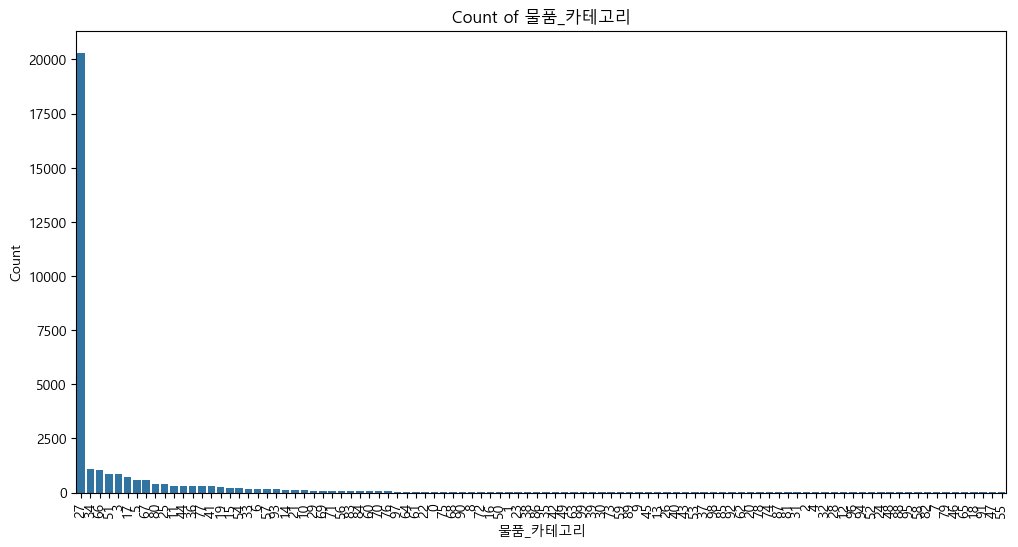

In [23]:
# 카테고리별 Count 그래프 -> 한 가지 물품 (27번 농산물)이 압도적으로 높음
plt.figure(figsize=(12, 6))
sns.countplot(data=train, x='물품_카테고리', order=train['물품_카테고리'].value_counts().index)
plt.title("Count of 물품_카테고리")
plt.xlabel("물품_카테고리")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

특정 물품 카테고리가 압도적으로 많이 등장하고 있음. 가장 빈도가 높은 물품 카테고리가 약 20,000건으로, 다른 카테고리에 비해 월등히 많습니다.
나머지 카테고리는 빈도가 상대적으로 낮으며, 긴 꼬리 형태로 분포.

농산물 -> 27

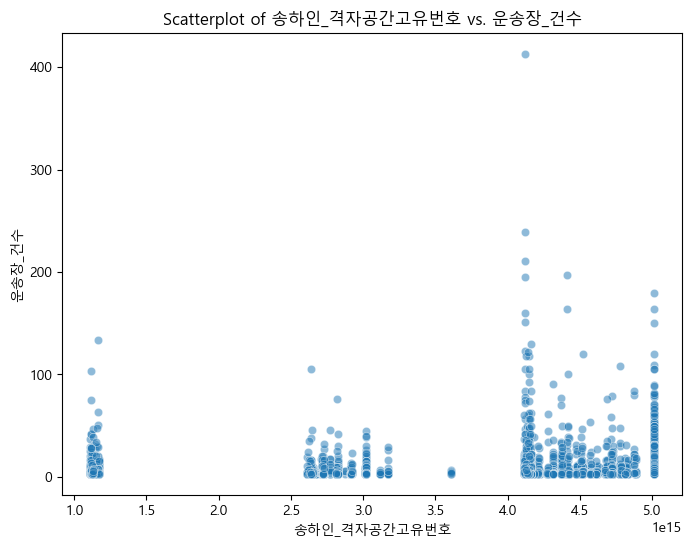

In [24]:
# 주요 변수 간 산점도 (운송장_건수와 송하인_격자공간고유번호) -> 의미없음
plt.figure(figsize=(8, 6))
sns.scatterplot(data=train, x='송하인_격자공간고유번호', y='운송장_건수', alpha=0.5)
plt.title("Scatterplot of 송하인_격자공간고유번호 vs. 운송장_건수")
plt.xlabel("송하인_격자공간고유번호")
plt.ylabel("운송장_건수")
plt.show()

- 상관관계 약함: 송하인_격자공간고유번호와 운송장_건수 간에는 뚜렷한 상관관계가 관찰되지 않습니다. 이는 격자 공간 번호가 운송장 건수를 예측하는 데 유용하지 않을 수 있음을 시사합니다.
- 극단치 처리 필요: 운송장_건수가 높은 일부 데이터는 극단치로 보이므로 분석 과정에서 별도로 처리하거나 검토하는 것이 좋을 것으로 보입니다.

범주형 변수(물품_카테고리 등)와 운송장_건수 간의 관계를 시각적으로 분석합니다.

C:\Users\Admin\AppData\Local\Temp\ipykernel_10256\3654772622.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=train, x='물품_카테고리', y='운송장_건수', estimator='mean', ci=None)


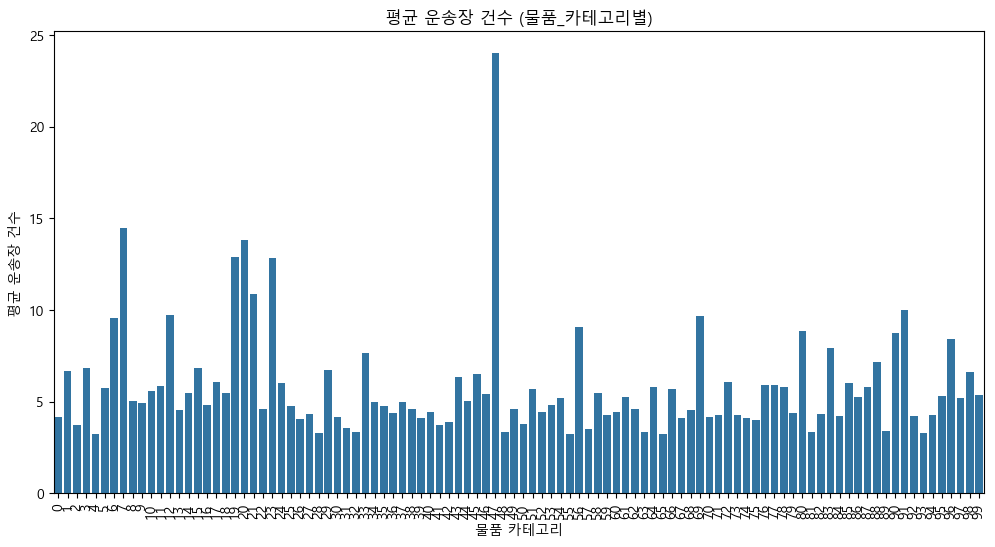

In [25]:
# 카테고리별 평균 운송장 건수 -> 특정 카테고리의 물품이 평균적으로 얼마나 많은 운송량을 기록하고 있는지 파악
plt.figure(figsize=(12, 6))
sns.barplot(data=train, x='물품_카테고리', y='운송장_건수', estimator='mean', ci=None)
plt.title("평균 운송장 건수 (물품_카테고리별)")
plt.xticks(rotation=90)
plt.xlabel("물품 카테고리")
plt.ylabel("평균 운송장 건수")
plt.show()

어떤 물품 카테고리가 물류량을 주도하는지 확인 가능한 그래프입니다.

특정 카테고리(47번)에서 평균 운송장_건수가 매우 높은 값을 보이고 있습니다. 데이터 수집 과정에서 해당 카테고리가 잘못 기록되었거나 실제로 특정 이벤트(세일 시즌)로 인해 물류량이 증가했을 수 있습니다.

대부분의 카테고리는 평균 운송장_건수가 5~15 사이에서 분포하고 있으며, 일부 카테고리가 평균적으로 더 많은 운송장 건수를 기록하고 있습니다.

-> 카테고리별 평균 운송장 건수를 새로운 피처로 추가할 수 있습니다. 모델링 시 물품 카테고리가 운송량에 얼마나 기여하는지 반영할 수 있습니다.

수하인_격자공간고유번호와 운송장_건수 간의 관계를 시각화합니다.

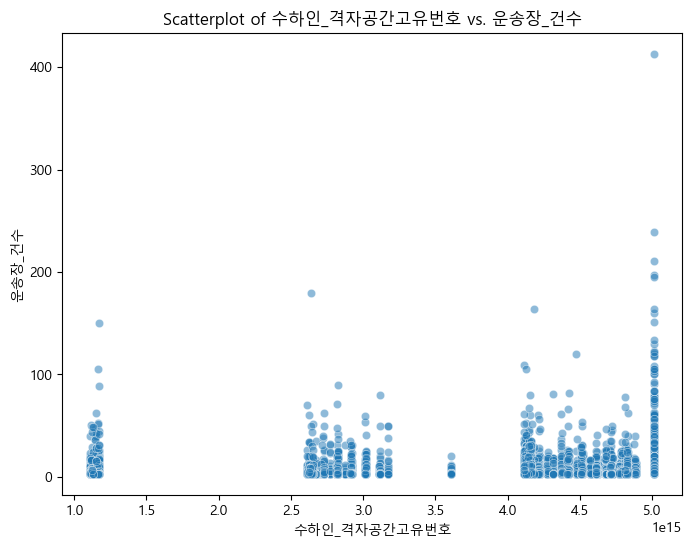

In [26]:
# 수하인_격자공간고유번호와 운송장_건수 간 산점도
plt.figure(figsize=(8, 6))
sns.scatterplot(data=train, x='수하인_격자공간고유번호', y='운송장_건수', alpha=0.5)
plt.title("Scatterplot of 수하인_격자공간고유번호 vs. 운송장_건수")
plt.xlabel("수하인_격자공간고유번호")
plt.ylabel("운송장_건수")
plt.show()

수하인_격자공간고유번호와 운송장_건수 간에는 직접적인 상관관계가 매우 약하거나 없는 것으로 보임. 이는 격자공간 고유 번호가 운송장_건수를 예측하는 데 주요 변수가 아닐 가능성을 시사합니다.

범주형 변수와 운송장_건수 간의 분포를 비교합니다.

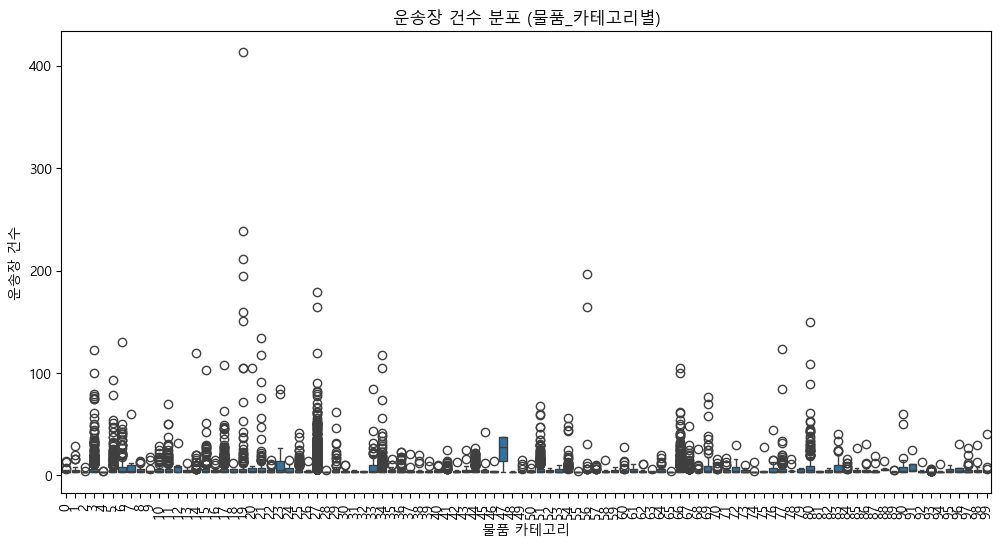

In [27]:
# 물품 카테고리별 운송장 건수 분포
plt.figure(figsize=(12, 6))
sns.boxplot(data=train, x='물품_카테고리', y='운송장_건수')
plt.title("운송장 건수 분포 (물품_카테고리별)")
plt.xticks(rotation=90)
plt.xlabel("물품 카테고리")
plt.ylabel("운송장 건수")
plt.show()

로그 변환된 운송장_건수를 다른 변수들과 비교하여 비대칭성을 완화한 상태에서 관계를 분석합니다.

### 변수별 기술 통계 확인

In [28]:
# 기술 통계 확인
print(train.describe(include='all'))

              index  송하인_격자공간고유번호  수하인_격자공간고유번호       물품_카테고리        운송장_건수  \
count  31684.000000  3.168400e+04  3.168400e+04  31684.000000  31684.000000   
mean   15841.500000  4.648814e+15  3.801369e+15     31.810409      4.879308   
std     9146.527301  8.341336e+14  1.314660e+15     16.899420      6.756473   
min        0.000000  1.111000e+15  1.111000e+15      0.000000      3.000000   
25%     7920.750000  4.713000e+15  2.826000e+15     27.000000      3.000000   
50%    15841.500000  5.011000e+15  4.159000e+15     27.000000      3.000000   
75%    23762.250000  5.013001e+15  5.011000e+15     27.000000      5.000000   
max    31683.000000  5.013001e+15  5.013001e+15     99.000000    413.000000   

         운송장_건수_log  
count  31684.000000  
mean       1.629110  
std        0.415760  
min        1.386294  
25%        1.386294  
50%        1.386294  
75%        1.791759  
max        6.025866  


### 격자공간고유번호 스케일 축소

앞 5자리는 시군구별 코드를 의미하기 때문에, 앞 5자리와 뒷 자리 숫자를 컬럼으로 나누기로 하였습니다.
https://bigdata-region.kr/#/dataset/0b9f68e9-e21e-42f6-8f88-6d8bbfdf8c44

In [29]:
# 송하인과 수하인의 격자공간고유번호를 앞 5자리와 나머지로 나누는 코드

# 열 이름 예시: 실제 데이터프레임의 열 이름을 사용해야 합니다.
송하인_열 = "송하인_격자공간고유번호"  # 실제 열 이름
수하인_열 = "수하인_격자공간고유번호"  # 실제 열 이름

In [30]:
# 송하인_격자공간고유번호 나누기
train['송하인_시군구코드'] = train[송하인_열].astype(str).str[:5]  # 앞 5자리 추출
train['송하인_고유번호'] = train[송하인_열].astype(str).str[5:]  # 나머지 추출

In [31]:
# 수하인_격자공간고유번호 나누기
train['수하인_시군구코드'] = train[수하인_열].astype(str).str[:5]  # 앞 5자리 추출
train['수하인_고유번호'] = train[수하인_열].astype(str).str[5:]  # 나머지 추출

In [32]:
# 결과 확인
print("송하인 및 수하인 격자공간 고유번호를 분리한 데이터프레임:")
print(train[[송하인_열, '송하인_시군구코드', '송하인_고유번호', 
             수하인_열, '수하인_시군구코드', '수하인_고유번호']].head())

송하인 및 수하인 격자공간 고유번호를 분리한 데이터프레임:
       송하인_격자공간고유번호 송하인_시군구코드     송하인_고유번호      수하인_격자공간고유번호 수하인_시군구코드  \
0  5011000595017300     50110  00595017300  2871000192069300     28710   
1  4148000690043300     41480  00690043300  5011000264024400     50110   
2  5011000078068400     50110  00078068400  1120000007005400     11200   
3  4127100048006400     41271  00048006400  5011000587019400     50110   
4  5011000078068400     50110  00078068400  2823700010076300     28237   

      수하인_고유번호  
0  00192069300  
1  00264024400  
2  00007005400  
3  00587019400  
4  00010076300  


C:\Users\Admin\AppData\Local\Temp\ipykernel_10256\3935791883.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=train, x='송하인_시군구코드', y='운송장_건수', estimator='mean', ci=None)


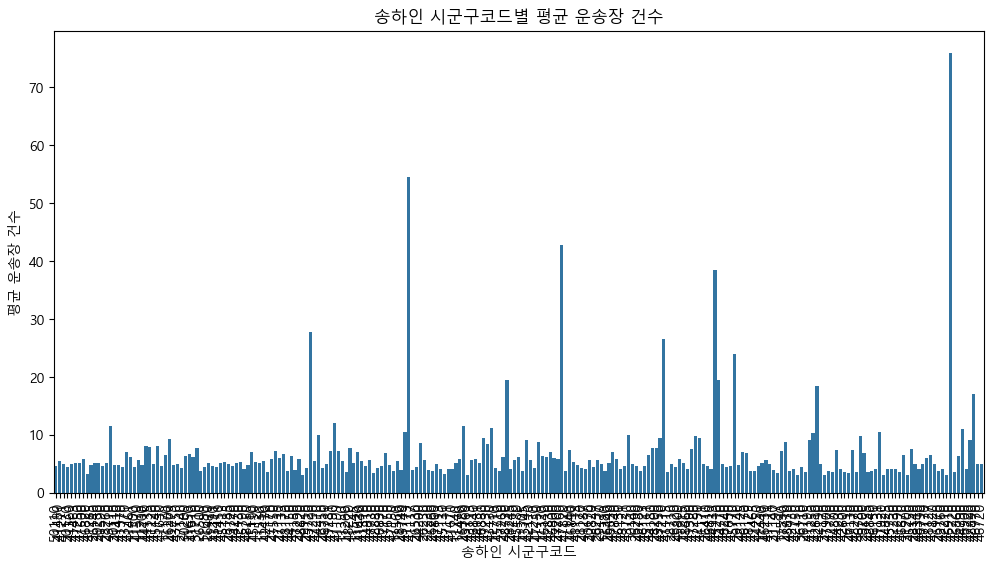

In [33]:
# 송하인 시군구코드와 운송장_건수 간 관계 시각화
plt.figure(figsize=(12, 6))
sns.barplot(data=train, x='송하인_시군구코드', y='운송장_건수', estimator='mean', ci=None)
plt.title("송하인 시군구코드별 평균 운송장 건수")
plt.xlabel("송하인 시군구코드")
plt.ylabel("평균 운송장 건수")
plt.xticks(rotation=90)
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_10256\3360358707.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=train, x='수하인_시군구코드', y='운송장_건수', estimator='mean', ci=None)


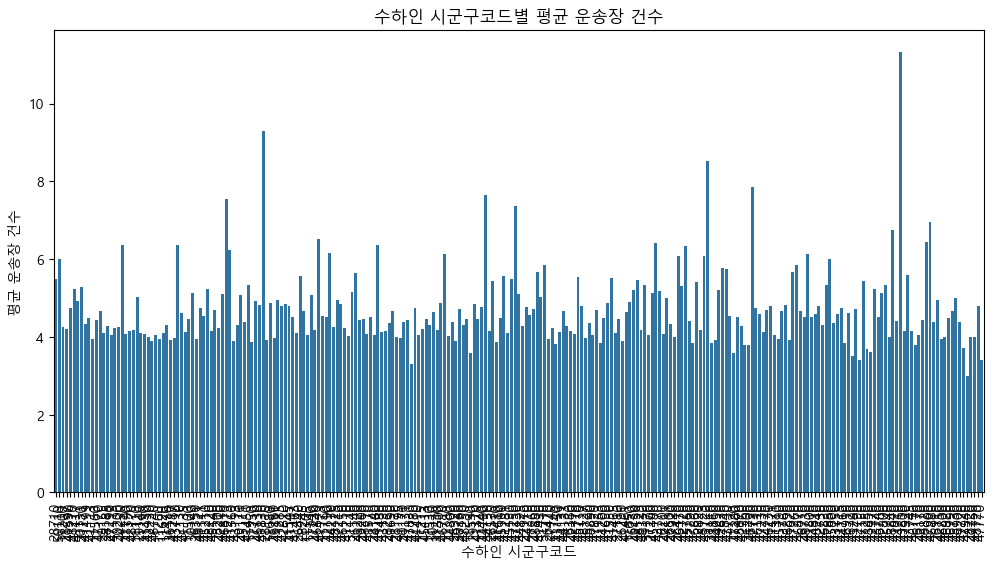

In [34]:
# 수하인 시군구코드와 운송장_건수 간 관계 시각화
plt.figure(figsize=(12, 6))
sns.barplot(data=train, x='수하인_시군구코드', y='운송장_건수', estimator='mean', ci=None)
plt.title("수하인 시군구코드별 평균 운송장 건수")
plt.xlabel("수하인 시군구코드")
plt.ylabel("평균 운송장 건수")
plt.xticks(rotation=90)
plt.show()

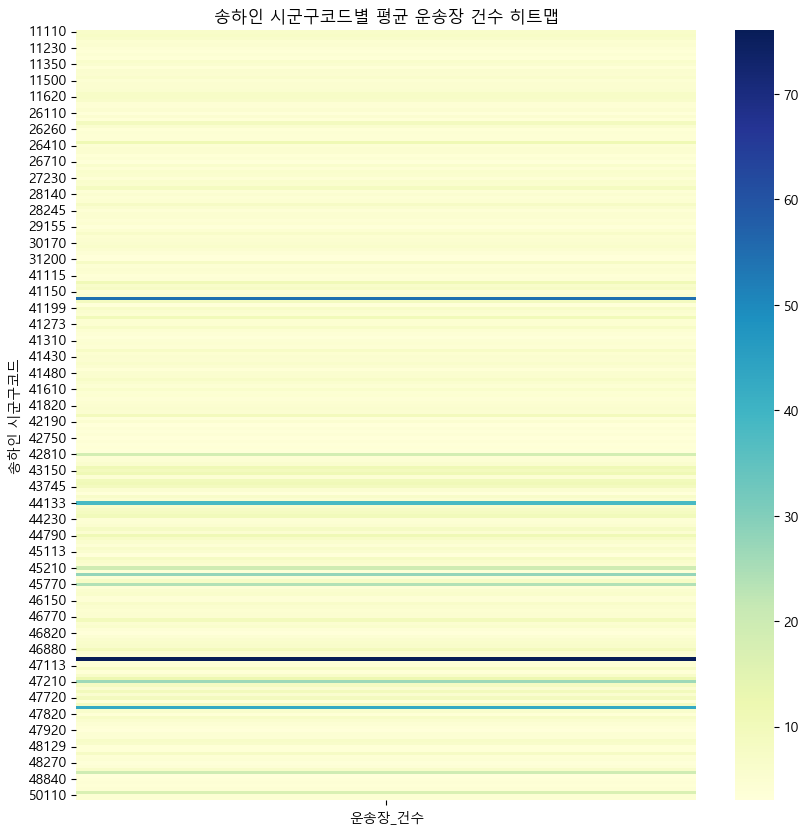

In [35]:
# 시군구코드별 평균 운송장 건수 피벗
pivot_data = train.pivot_table(index='송하인_시군구코드', values='운송장_건수', aggfunc='mean')

plt.figure(figsize=(10, 10))
sns.heatmap(pivot_data, cmap="YlGnBu", annot=False, cbar=True)
plt.title("송하인 시군구코드별 평균 운송장 건수 히트맵")
plt.ylabel("송하인 시군구코드")
plt.show()

대부분의 시군구코드는 평균 운송장 건수가 낮은 편(밝은 색)으로 나타납니다. 일부 시군구코드는 평균 운송장 건수가 매우 높은 값(어두운 색)으로 나타납니다. 이는 극소수의 시군구코드만 높은 운송장 건수를 기록하며, 데이터의 편중이 존재함을 알 수 있습니다. 높은 운송장 건수를 기록한 몇몇 시군구코드는 데이터 분석 및 모델링에서 중요한 변수로 작용할 수 있습니다.

특정 시군구코드(예: 44133, 46820 등)가 평균 운송장 건수가 50~70 사이로 매우 높은 값을 가집니다. 이러한 지역은 운송장 건수에서 중요한 기여를 하고 있는 지역으로 보입니다.

In [36]:
# 송하인 기준 상위 10개 시군구코드 추출
송하인_운송량 = train.groupby('송하인_시군구코드')['운송장_건수'].sum().reset_index()
송하인_운송량 = 송하인_운송량.sort_values(by='운송장_건수', ascending=False).head(10)

print("송하인 기준 상위 10개 시군구코드의 운송량:")
print(송하인_운송량)

송하인 기준 상위 10개 시군구코드의 운송량:
    송하인_시군구코드  운송장_건수
235     50110   60067
236     50130   46515
105     41480    6470
99      41410    2256
106     41500    1992
109     41590    1826
102     41461    1748
82      41173    1745
96      41360    1514
108     41570    1419


송하인 기준으로 가장 많은 운송장 건수를 기록한 시군구코드는 50110으로, 총 69,067건을 기록했습니다. 운송장 건수의 분포는 상위 시군구코드에서 매우 집중되어 있으며, 이는 주요 발송 지역이 몇몇 시군구코드에 편중되어 있음을 나타냅니다.

In [37]:
# 수하인 기준 상위 10개 시군구코드 추출
수하인_운송량 = train.groupby('수하인_시군구코드')['운송장_건수'].sum().reset_index()
수하인_운송량 = 수하인_운송량.sort_values(by='운송장_건수', ascending=False).head(10)

print("\n수하인 기준 상위 10개 시군구코드의 운송량:")
print(수하인_운송량)


수하인 기준 상위 10개 시군구코드의 운송량:
    수하인_시군구코드  운송장_건수
249     50110   38246
250     50130   10858
111     41590    2188
22      11680    1815
23      11710    1530
21      11650    1320
92      41273    1268
15      11500    1217
98      41360    1162
53      28200    1123


마찬가지로, 주요 수신 지역도 특정 시군구코드에 집중되어 있음을 보여줍니다.

* 비즈니스 인사이트 도출
1. 주요 발송/수신 지역 식별: 송하인 기준과 수하인 기준 상위 시군구코드를 식별하여, 해당 지역이 운송 네트워크에서 얼마나 중요한 역할을 하는지 파악할 수 있습니다. 이를 통해 주요 물류 허브 지역을 정의할 수 있습니다.

2. 운송 네트워크 최적화: 상위 시군구코드에서 발송 및 수신되는 물류량을 고려하여 물류 네트워크를 최적화할 수 있습니다. 예를 들어, 50110 지역이 송하인과 수하인 모두에서 상위에 위치하므로, 이 지역의 물류 처리 용량을 확대하거나 운송 경로를 최적화할 필요가 있을 수 있습니다.

3. 리소스 할당: 물류량이 많은 상위 지역에 더 많은 운송 리소스(예: 차량, 인력)를 배치하여 처리 효율성을 높일 수 있습니다. 물류량이 적은 지역은 비용 절감을 위한 조치를 고려할 수 있습니다.

4. 지역별 물류 특성 분석: 상위 시군구코드가 특정 유형의 물품 운송에 특화되었는지 확인하여, 지역 맞춤형 물류 전략을 개발할 수 있습니다.

### 파생 변수 생성

In [38]:
# 송하인/수하인 시군구코드별 평균 운송장 건수 계산
train['송하인_시군구코드'] = train['송하인_격자공간고유번호'].astype(str).str[:5]
train['수하인_시군구코드'] = train['수하인_격자공간고유번호'].astype(str).str[:5]

송하인_평균_운송장 = train.groupby('송하인_시군구코드')['운송장_건수'].mean().rename('송하인_시군구코드별_평균_운송장_건수')
수하인_평균_운송장 = train.groupby('수하인_시군구코드')['운송장_건수'].mean().rename('수하인_시군구코드별_평균_운송장_건수')

train = train.merge(송하인_평균_운송장, on='송하인_시군구코드', how='left')
train = train.merge(수하인_평균_운송장, on='수하인_시군구코드', how='left')

In [39]:
# 송하인/수하인 운송량 (총합) 계산
송하인_운송량 = train.groupby('송하인_시군구코드')['운송장_건수'].sum().rename('송하인_운송량')
수하인_운송량 = train.groupby('수하인_시군구코드')['운송장_건수'].sum().rename('수하인_운송량')

train = train.merge(송하인_운송량, on='송하인_시군구코드', how='left')
train = train.merge(수하인_운송량, on='수하인_시군구코드', how='left')

In [40]:
# 카테고리별 운송장 건수 카운트 계산
카테고리_운송장_건수_카운트 = train.groupby('물품_카테고리')['운송장_건수'].count().rename('카테고리_운송장_건수_카운트')
train = train.merge(카테고리_운송장_건수_카운트, on='물품_카테고리', how='left')

In [41]:
# 시군구코드 추출
train['송하인_시군구코드'] = train['송하인_격자공간고유번호'].astype(str).str[:5]
train['수하인_시군구코드'] = train['수하인_격자공간고유번호'].astype(str).str[:5]
# 조합 변수 생성
train['송수하인_시군구_조합'] = train['송하인_시군구코드'] + '_' + train['수하인_시군구코드']

In [42]:
# 단일거래/다중거래 여부
# 송수하인 조합 기준 거래 횟수 계산
transaction_counts = train.groupby('송수하인_시군구_조합')['운송장_건수'].count().rename('송수하인_거래횟수')
train = train.merge(transaction_counts, on='송수하인_시군구_조합', how='left')
# 거래 여부 플래그 생성
train['거래유형'] = train['송수하인_거래횟수'].apply(lambda x: '다중거래' if x > 20 else '단일거래')

In [43]:
# 결과 확인
print(train[['물품_카테고리', '송수하인_시군구_조합', '거래유형']].head())

   물품_카테고리  송수하인_시군구_조합  거래유형
0       67  50110_28710  단일거래
1       34  41480_50110  다중거래
2       27  50110_11200  다중거래
3       17  41271_50110  다중거래
4       27  50110_28237  다중거래


In [44]:
print(transaction_counts)

송수하인_시군구_조합
11110_50110     34
11110_50130     13
11140_50110     27
11140_50130     14
11170_50110    145
              ... 
50130_48870      8
50130_48880     18
50130_48890      8
50130_50110     25
50130_50130     28
Name: 송수하인_거래횟수, Length: 926, dtype: int64


In [45]:
# 거래 횟수의 통계량 계산
average_count = transaction_counts.mean()
min_count = transaction_counts.min()
median_count = transaction_counts.median()

# 결과 출력
print("송수하인_거래횟수의 평균값:", average_count)
print("송수하인_거래횟수의 최소값:", min_count)
print("송수하인_거래횟수의 중간값:", median_count)

송수하인_거래횟수의 평균값: 34.21598272138229
송수하인_거래횟수의 최소값: 1
송수하인_거래횟수의 중간값: 15.0


다중거래 기준을 20회라고 한 이유

### Feature Importance 확인

In [46]:
print(train.columns)

Index(['index', '송하인_격자공간고유번호', '수하인_격자공간고유번호', '물품_카테고리', '운송장_건수',
       '운송장_건수_log', '송하인_시군구코드', '송하인_고유번호', '수하인_시군구코드', '수하인_고유번호',
       '송하인_시군구코드별_평균_운송장_건수', '수하인_시군구코드별_평균_운송장_건수', '송하인_운송량', '수하인_운송량',
       '카테고리_운송장_건수_카운트', '송수하인_시군구_조합', '송수하인_거래횟수', '거래유형'],
      dtype='object')


In [47]:
# 1. 사용할 변수와 타겟 변수 선택
feature_columns = [
    '카테고리_운송장_건수_카운트',  # 카테고리별 평균 운송장 건수
    '송하인_시군구코드별_평균_운송장_건수',  # 송하인 시군구코드별 평균 운송장 건수
    '수하인_시군구코드별_평균_운송장_건수',  # 수하인 시군구코드별 평균 운송장 건수
    '송하인_운송량',  # 송하인 운송량(운송장 건수 총합)
    '수하인_운송량',  # 수하인 운송량(운송장 건수 총합)
    '카테고리_운송장_건수_카운트',  # 카테고리별 운송장 건수 카운트
]

X = train[feature_columns]
y = train['운송장_건수']  # 타겟 변수

In [48]:
# 데이터 분할
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

In [49]:
# 랜덤포레스트 모델 학습
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [50]:
# Feature Importance 추출
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

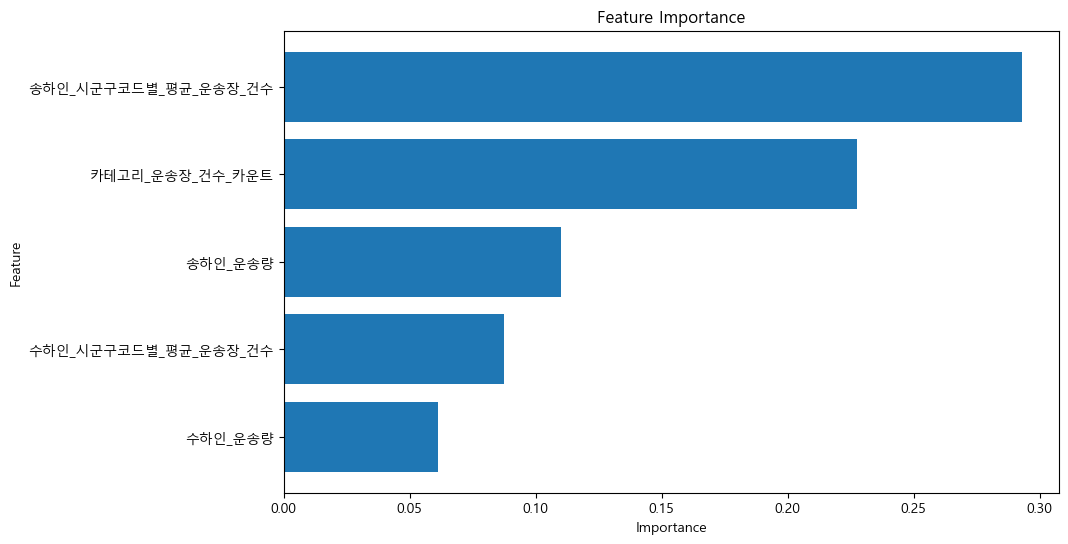

In [51]:
# Feature Importance 시각화
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.gca().invert_yaxis()  # 중요도가 높은 변수를 상단에 배치
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [52]:
# 모델 성능 확인 (RMSE 계산)
y_pred = model.predict(X_valid)
rmse = mean_squared_error(y_valid, y_pred, squared=False)
print("모델의 RMSE:", rmse)

모델의 RMSE: 6.392366738888548


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


*추가 변수 생성하기*

In [53]:
# 송수하인 간 거리 대체 변수 (시군구코드가 같으면 0, 다르면 1)
train['송수하인_거리'] = (train['송하인_시군구코드'] != train['수하인_시군구코드']).astype(int)

In [54]:
# 카테고리와 지역의 상호작용 변수 (카테고리 + 송하인 시군구코드 조합)
train['카테고리_송하인조합'] = train['물품_카테고리'].astype(str) + '_' + train['송하인_시군구코드']

In [55]:
# 상호작용 변수에 따른 평균 운송장 건수
카테고리_송하인_평균 = train.groupby('카테고리_송하인조합')['운송장_건수'].mean().rename('카테고리_송하인_평균_운송장_건수')
train = train.merge(카테고리_송하인_평균, on='카테고리_송하인조합', how='left')

In [56]:
# 로그 변환된 운송장 건수 (타겟 변수에 로그 변환)
train['운송장_건수_log'] = np.log1p(train['운송장_건수'])

In [57]:
# 사용할 변수와 타겟 변수 선택
feature_columns = [
    '송하인_시군구코드별_평균_운송장_건수',
    '수하인_시군구코드별_평균_운송장_건수',
    '송하인_운송량',
    '수하인_운송량',
    '카테고리_운송장_건수_카운트',
    '송수하인_거리',
    '카테고리_송하인_평균_운송장_건수'
]

In [58]:
X = train[feature_columns]
y = train['운송장_건수_log']  # 로그 변환된 타겟 변수

In [59]:
# 데이터 분할
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

In [60]:
# 랜덤포레스트 모델 학습
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [61]:
# Feature Importance 추출
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

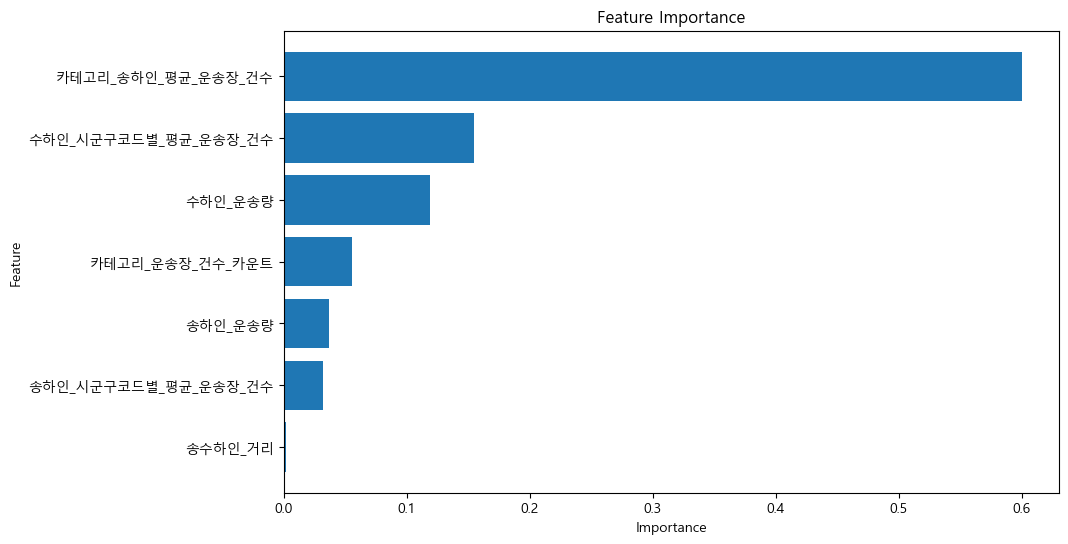

In [62]:
# Feature Importance 시각화
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.gca().invert_yaxis()  # 중요도가 높은 변수를 상단에 배치
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [63]:
# 모델 성능 확인 (RMSE 계산)
y_pred = model.predict(X_valid)
rmse = mean_squared_error(y_valid, y_pred, squared=False)
print("모델의 RMSE:", rmse)

모델의 RMSE: 0.388865394953871


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


- 카테고리_송하인_평균_운송장_건수: 가장 중요한 변수로 확인되었습니다. 이 변수는 카테고리와 송하인 지역의 상호작용을 반영한 변수로, 특정 카테고리-지역 조합이 물류량에 큰 영향을 미친다는 것을 의미합니다. 물류 시스템에서 특정 지역이 특정 카테고리의 물류 허브 역할을 한다고 볼 수 있습니다.

- 수하인_시군구코드별_평균_운송장_건수: 두번째로 중요한 변수입니다. 수하인 지역의 특성이 운송장 건수에 강하게 영향을 미친다고 해석할 수 있습니다. 이는 도착지의 수요 패턴이나 지역의 물류 집중도가 중요하다는 것을 나타냅니다.

- 수하인_운송량: 세번째로 중요한 변수입니다. 수하인 지역에서 발생한 전체 물류량이 타겟 변수에 기여하는 정도를 보여줍니다. 이는 특정 지역이 많은 물량을 소화하는 주요 목적지로 작용한다는 것을 나타냅니다.

- 카테고리별_평균_운송장_건수: 중간 정도의 중요도로 나타났습니다. 카테고리별 물류량 패턴은 영향을 미치지만, 지역 특성만큼 강한 영향은 없다고 볼 수 있었습니다.

- 송하인_운송량 및 송하인_시군구코드별_평균_운송장_건수: 상대적으로 낮은 중요도를 보였습니다. 이는 송하인 지역의 특성이 수하인 지역이나 카테고리-지역 조합에 비해 타겟 변수에 덜 영향을 미친다고 해석할 수 있습니다.

- 송수하인_거리: 가장 낮은 중요도를 보였습니다. 송하인과 수하인 간 거리가 물류량에 큰 영향을 미치지 않는 것으로 보입니다. 이는 물리적 거리보다는 지역 특성과 카테고리 특성이 더 중요한 역할을 한다는 것을 나타냅니다.

### 추가적으로 Feature Importance 확인 (LightGBM 및 XGBoost)

In [64]:
!pip install lightgbm xgboost

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
import xgboost as xgb

In [66]:
# 사용할 변수와 타겟 변수 선택
feature_columns = [
    '송하인_시군구코드별_평균_운송장_건수',
    '수하인_시군구코드별_평균_운송장_건수',
    '송하인_운송량',
    '수하인_운송량',
    '카테고리_운송장_건수_카운트',
    '송수하인_거리',
    '카테고리_송하인_평균_운송장_건수'
]

X = train[feature_columns]
y = train['운송장_건수_log']  # 로그 변환된 타겟 변수

In [67]:
# 데이터 분할
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

In [68]:
# 1. LightGBM 모델링
lgb_model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
lgb_model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000463 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1071
[LightGBM] [Info] Number of data points in the train set: 25347, number of used features: 7
[LightGBM] [Info] Start training from score 1.628417


LGBMRegressor(random_state=42)

In [69]:
# LightGBM 예측 및 평가
y_pred_lgb = lgb_model.predict(X_valid)
rmse_lgb = mean_squared_error(y_valid, y_pred_lgb, squared=False)
print("LightGBM RMSE:", rmse_lgb)

LightGBM RMSE: 0.3667658588581115


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [70]:
# 2. XGBoost 모델링
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, use_label_encoder=False)
xgb_model.fit(X_train, y_train)

C:\Users\Admin\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [15:28:16] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [71]:
# XGBoost 예측 및 평가
y_pred_xgb = xgb_model.predict(X_valid)
rmse_xgb = mean_squared_error(y_valid, y_pred_xgb, squared=False)
print("XGBoost RMSE:", rmse_xgb)

XGBoost RMSE: 0.37010399487626683


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


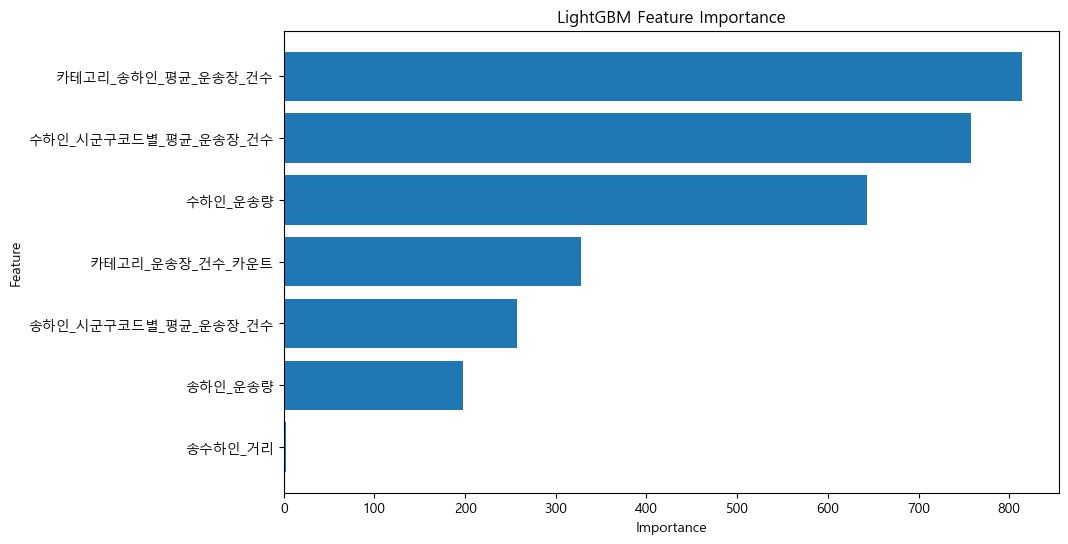

In [72]:
# 3. Feature Importance 시각화 (LightGBM)
import matplotlib.pyplot as plt

lgb_importances = lgb_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': lgb_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.gca().invert_yaxis()  # 중요도가 높은 변수를 상단에 배치
plt.title('LightGBM Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

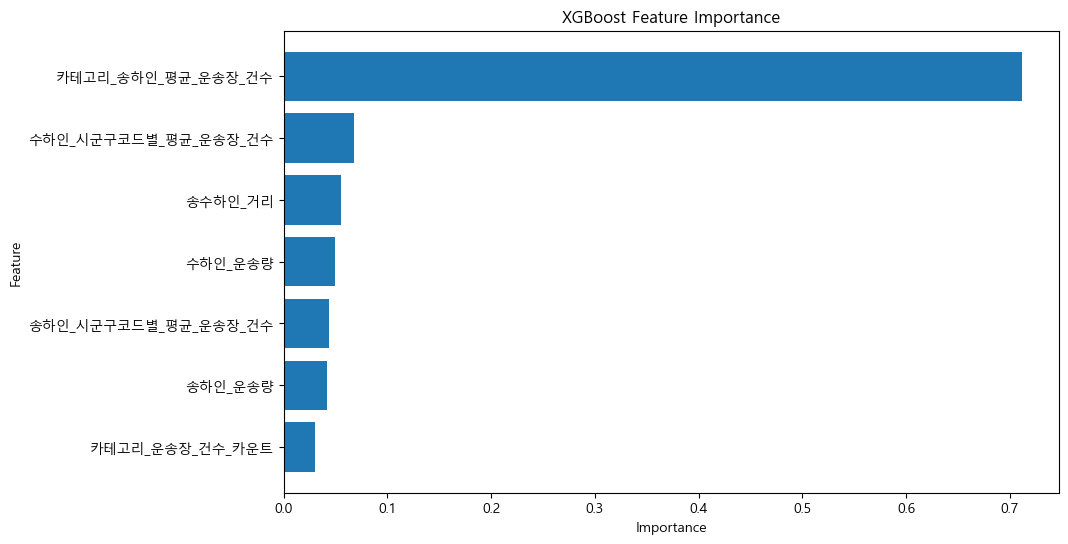

In [73]:
# 4. Feature Importance 시각화 (XGBoost)
xgb_importances = xgb_model.feature_importances_
feature_importance_df_xgb = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': xgb_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df_xgb['Feature'], feature_importance_df_xgb['Importance'])
plt.gca().invert_yaxis()  # 중요도가 높은 변수를 상단에 배치
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

### 하이퍼파라미터 튜닝

In [74]:
from sklearn.model_selection import GridSearchCV

In [75]:
# 하이퍼파라미터 그리드 설정
param_grid = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [5, 7, 10],
    'num_leaves': [20, 31, 40],
    'min_child_samples': [10, 20, 30]
}

In [76]:
# LightGBM 모델과 그리드 서치 설정
lgb_model = lgb.LGBMRegressor(random_state=42)
grid_search = GridSearchCV(estimator=lgb_model, param_grid=param_grid, cv=3, scoring='neg_root_mean_squared_error', verbose=1)

In [ ]:
# 그리드 서치 실행
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 243 candidates, totalling 729 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000214 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1051
[LightGBM] [Info] Number of data points in the train set: 16898, number of used features: 7
[LightGBM] [Info] Start training from score 1.631131
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000204 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1046
[LightGBM] [Info] Number of data points in the train set: 16898, number of used features: 7
[LightGBM] [Info] Start training from score 1.627505
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000157 seconds.
You can set `force_row_

In [83]:
# 최적 하이퍼파라미터와 점수 확인
print("최적 하이퍼파라미터:", grid_search.best_params_)
print("최적 RMSE:", -grid_search.best_score_)

최적 하이퍼파라미터: {'learning_rate': 0.01, 'max_depth': 5, 'min_child_samples': 10, 'n_estimators': 300, 'num_leaves': 20}
최적 RMSE: 0.36983660789140393


In [84]:
import lightgbm as lgb
from lightgbm import LGBMRegressor
from lightgbm.callback import early_stopping, log_evaluation

In [85]:
# LightGBM 모델 설정
final_lgb_model = LGBMRegressor(
    learning_rate=0.01,
    max_depth=5,
    min_child_samples=10,
    n_estimators=300,
    num_leaves=20,
    random_state=42
)

In [86]:
# 콜백 설정
callbacks = [
    early_stopping(stopping_rounds=50),  # 조기 종료 설정
    log_evaluation(period=10)  # 10회마다 로그 출력
]

In [87]:
# 모델 학습
final_lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='rmse',
    callbacks=callbacks
)

NameError: name 'X_test' is not defined

### 잔차분석

In [88]:
# 잔차 계산
residuals = np.expm1(y_test) - np.expm1(y_pred)

# 잔차 시각화
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(np.expm1(y_test), residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals Plot')
plt.xlabel('Actual Values')
plt.ylabel('Residuals')
plt.show()

NameError: name 'y_test' is not defined

### 모델 통합 및 예측

In [89]:
# 필요한 라이브러리 임포트
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import numpy as np

# 데이터 로드
test_path = 'C:/Users/Admin/Desktop/dacon_data/test.csv'
test = pd.read_csv(test_path)

# sample_submission 로드
sample_submission_path = 'C:/Users/Admin/Desktop/dacon_data/sample_submission.csv'
sample_submission = pd.read_csv(sample_submission_path)

In [90]:
# 동일한 전처리 적용
# 1. 송하인/수하인 시군구코드 생성
test['송하인_시군구코드'] = test['송하인_격자공간고유번호'].astype(str).str[:5]
test['수하인_시군구코드'] = test['수하인_격자공간고유번호'].astype(str).str[:5]

# 2. 거리 변수 생성
test['송수하인_거리'] = (test['송하인_시군구코드'] != test['수하인_시군구코드']).astype(int)

# 3. 카테고리 Label Encoding
label_encoder = LabelEncoder()
test['물품_카테고리'] = label_encoder.fit_transform(test['물품_카테고리'])

# 4. 카테고리와 송하인 조합 변수 생성
test['카테고리_송하인조합'] = test['물품_카테고리'].astype(str) + '_' + test['송하인_시군구코드']

In [91]:
# Train 데이터에서 계산된 평균 값을 활용
송하인_평균_운송장 = train.groupby('송하인_시군구코드')['운송장_건수'].mean().rename('송하인_시군구코드별_평균_운송장_건수')
수하인_평균_운송장 = train.groupby('수하인_시군구코드')['운송장_건수'].mean().rename('수하인_시군구코드별_평균_운송장_건수')

# Test 데이터에 적용
test = test.merge(송하인_평균_운송장, on='송하인_시군구코드', how='left')
test = test.merge(수하인_평균_운송장, on='수하인_시군구코드', how='left')

In [92]:
# Train 데이터에서 총 운송량 계산
송하인_운송량 = train.groupby('송하인_시군구코드')['운송장_건수'].sum().rename('송하인_운송량')
수하인_운송량 = train.groupby('수하인_시군구코드')['운송장_건수'].sum().rename('수하인_운송량')

# Test 데이터에 적용
test = test.merge(송하인_운송량, on='송하인_시군구코드', how='left')
test = test.merge(수하인_운송량, on='수하인_시군구코드', how='left')

In [93]:
# Train 데이터에서 카테고리별 카운트 계산
카테고리_운송장_건수_카운트 = train.groupby('물품_카테고리')['운송장_건수'].count().rename('카테고리_운송장_건수_카운트')

# Test 데이터에 적용
test = test.merge(카테고리_운송장_건수_카운트, on='물품_카테고리', how='left')

In [94]:
# Train 데이터에서 카테고리-송하인 조합별 평균 운송장 건수 계산
카테고리_송하인_평균 = train.groupby('카테고리_송하인조합')['운송장_건수'].mean().rename('카테고리_송하인_평균_운송장_건수')

# Test 데이터에 적용
test = test.merge(카테고리_송하인_평균, on='카테고리_송하인조합', how='left')

In [95]:
from lightgbm import LGBMRegressor

# 최적 하이퍼파라미터를 기반으로 최종 모델 정의
final_lgb_model = LGBMRegressor(
    learning_rate=0.01,
    max_depth=5,
    min_child_samples=10,
    n_estimators=300,
    num_leaves=20,
    random_state=42
)

In [96]:
# 모델 학습 (train 데이터를 사용해 학습)
X_train = train[feature_columns]
y_train = train['운송장_건수_log']  # 로그 변환된 타겟 변수

final_lgb_model.fit(X_train, y_train)

# 테스트 데이터에서 사용할 변수 선택
X_test = test[feature_columns]

# 예측 수행 (로그 변환 해제)
test_predictions_log = final_lgb_model.predict(X_test)
test_predictions = np.expm1(test_predictions_log)  # 로그 변환 해제

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000317 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1081
[LightGBM] [Info] Number of data points in the train set: 31684, number of used features: 7
[LightGBM] [Info] Start training from score 1.629110


In [99]:
from sklearn.model_selection import train_test_split

# Train 데이터를 학습(train)과 검증(valid)으로 분리
X = train[feature_columns]  # 입력 변수
y = train['운송장_건수_log']  # 로그 변환된 타겟 변수

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

In [100]:
from sklearn.metrics import mean_squared_error
import numpy as np

# 검증 데이터 예측
valid_predictions_log = final_lgb_model.predict(X_valid)

# 로그 변환 해제
valid_predictions = np.expm1(valid_predictions_log)  # 예측값 로그 해제
y_valid_actual = np.expm1(y_valid)  # 실제값 로그 해제

# RMSE 계산
rmse = np.sqrt(mean_squared_error(y_valid_actual, valid_predictions))
print(f"Final RMSE: {rmse}")

Final RMSE: 5.301005277127962


In [98]:
# submission 데이터에 결과 입력
sample_submission['운송장_건수'] = test_predictions

# 결과 저장
submission_path = 'C:/Users/Admin/Desktop/dacon_data/sample_submission.csv'
sample_submission.to_csv(submission_path, index=False)

print(f"최종 결과가 {submission_path}에 저장되었습니다!")

최종 결과가 C:/Users/Admin/Desktop/dacon_data/sample_submission.csv에 저장되었습니다!
